In [22]:
import os
from pathlib import Path
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr 
import hydromt
from hydromt._utils import log
from hydromt_sfincs import SfincsModel
from sfincs_utils import run_sfincs
from hydromt import DataCatalog
from shapely.geometry import Point
import pandas as pd
import numpy as np
from pyproj import Transformer

log.initialize_logging()
log.set_log_level(log_level=20)
proj = ccrs.PlateCarree()

main_dir = Path(r"C:\PhD\SFINCS\SFINCS_cloned\input")

# 1a: Configure model - data catalog -----------------------------------------------------
catalog = hydromt.DataCatalog(data_libs = ['data_catalog_v1.yml']) 

# 1b: Configure model - define model domain ----------------------------------------------------
deltas = catalog.get_geodataframe('40_delta_polygons')

# Deltas
target_basin_id = 620947 # small delta in australia (test)

# target_basin_id = 1416812 # zambezi -- slighlty changed geojson to include whole coast 
# target_basin_id = 2433835 # ebro 
# target_basin_id = 2180336 # indus 

region = deltas[deltas['BasinID2'] == target_basin_id]

# Load the hydrobasins that intersect with the selected delta
gdf_basin = catalog.get_geodataframe(
    'hydrobasins_global',
    geom=region # only load basins that intersect with our region of interest
)

# Create a combined polygon from all the basins that overlap with the delta
dissolved_basins = gdf_basin.dissolve()  # Dissolve all overlapping basins
total_polygon = dissolved_basins.overlay(region, how='union').dissolve() # this works for aus but not zambezi 

# Initialise model --------------------------------------------------------
root_folder  = Path('C:/PhD/SFINCS/SFINCS_cloned/output') / f'sfincs_{target_basin_id}_spinup'

# NOTSET=0-9, DEBUG=10, INFO=20, WARNING=30, ERROR=40, CRITICAL=50 # added. 
log.initialize_logging()
log.set_log_level(log_level=20)

# Add file handler to log to a file
log_file = Path(root_folder) / "hydromt_sfincs.log"
logger = log._add_filehandler(log_file)


sf = SfincsModel(
    data_libs= ["data_catalog_v1.yml"],         # specify which data libraries to use
    root= root_folder,                          # specify the root directory for the model
    mode="w+",                                  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite
    write_gis=True,                             # specify whether to write GIS data
)

2026-01-31 09:43:51,275 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-31 09:43:51,326 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading 40_delta_polygons GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\40_delta_polygons.geojson
2026-01-31 09:43:51,348 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading hydrobasins_global GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\hydrobasins_global.gpkg
2026-01-31 09:43:51,513 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-31 09:43:51,587 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-01-31 09:43:51,589 - hydromt.model.model - model - WARNING - No region component found in components.


In [23]:
# Print all data source names source names in catalogs
sources = list(catalog.sources.keys())
for i, source in enumerate(sources, 1):
    print(f"{i}. {source}")

1. 40_delta_polygons
2. coastal_boundary_polygons
3. aus_obs_points
4. hydrobasins_global
5. global_rivers_lin
6. merit
7. gebco
8. esa_worldcover
9. esa_worldcover_mapping
10. gcn250
11. combined_dataset_deltas
12. deltadtm
13. osm_water
14. gtsm_codec_reanalysis_waterlevel_hourly
15. merit_hydro


In [24]:
# print global_rivers variables 
rivers_clipped = catalog.get_geodataframe("global_rivers_lin", geom=total_polygon)
print(rivers_clipped.columns)

2026-01-31 09:43:54,185 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading global_rivers_lin GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\rivers_lin.gpkg
Index(['COMID', 'order', 'area', 'Sin', 'Slp', 'Elev', 'K', 'P', 'AI', 'LAI',
       'SND', 'CLY', 'SLT', 'Urb', 'WTD', 'HW', 'DOR', 'QMEAN', 'Q2', 'rivwth',
       'width_DHG', 'geometry'],
      dtype='object')


2026-01-31 09:44:01,384 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading osm_water GeoDataFrame data from P:\wflow_global\hydromt\geography\osm\osm_coastlines-db.gpkg
2026-01-31 09:44:01,499 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading coastal_boundary_polygons GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\coastal_boundary_polygons.geojson


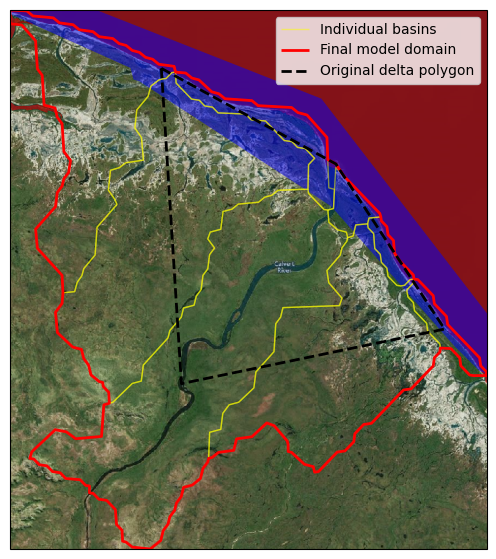

In [25]:
# Visualize the combined polygon
fig = plt.figure(figsize=(10,7))
ax = plt.subplot(projection=proj)
ax.add_image(cimgt.QuadtreeTiles(), 12)

# Plot the individual basin boundaries 
gdf_basin['geometry'].boundary.plot(ax=ax, label='Individual basins', lw=1, color='yellow', alpha=0.5)
total_polygon.boundary.plot(ax=ax, label='Final model domain', lw=2, color='red')
region.boundary.plot(ax=ax, color='k', label='Original delta polygon', lw=2, linestyle='--')

# Load and plot coastlines near the delta region
global_water = catalog.get_geodataframe('osm_water', geom=total_polygon)
global_water.plot(ax=ax, color='red', label='Coastline', alpha = 0.5)

# plot the coastal boundary layer 
zambezi_waterlevel_boundary = catalog.get_geodataframe('coastal_boundary_polygons', geom=total_polygon)
zambezi_waterlevel_boundary.plot(ax=ax, color='blue', label='Coastal boundary layer', alpha = 0.5)

ax.set_extent(gdf_basin['geometry'].total_bounds[[0,2,1,3]], crs=proj)
ax.legend()
plt.show()

2026-01-31 09:44:01,914 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 9 attributes in model config.


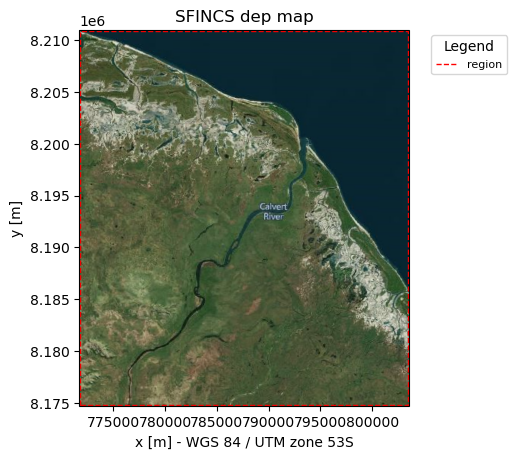

In [26]:
# 2:Define model grid --------------------------------------------------------

sf.grid.create_from_region(
    # region = {'bbox': total_polygon.to_crs('EPSG:4326').total_bounds},  # use combined polygon for model domain (also works)
    region = {'geom': total_polygon},  # use combined polygon for model domain
    res = 100, # 100m resolution 
    rotated=False, # non-rotated grid. 
    crs='utm' # automatically the closest UTM zone is selected (unit is in meters), 
)

fig, ax = sf.plot_basemap(plot_region=True,bmap='sat')

2026-01-31 09:44:04,276 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit RasterDataset data from P:\wflow_global\hydromt\topography\merit\merit.nc
2026-01-31 09:44:04,625 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from P:\wflow_global\hydromt\bathymetry\gebco\gebco.vrt


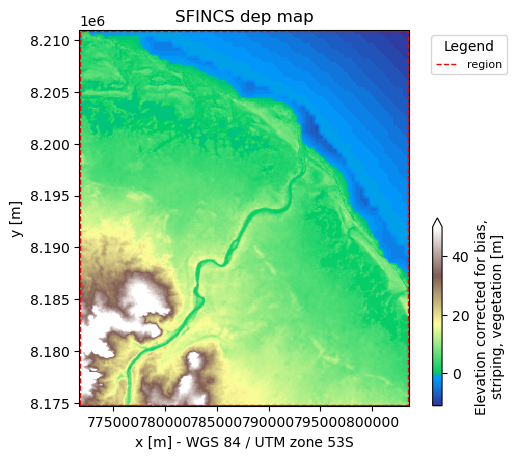

In [27]:
elevation_list = [
    # {'elevation': 'deltadtm', 'zmin': 0.001},
    {'elevation': 'merit', 'zmin': 0.001},  # merit looks higher resolution
    {'elevation': 'gebco'}
]

dep = sf.elevation.create(elevation_list = elevation_list)

# Plot the elevation on top of the model region and satellite image. The variable argument sets which model variable to plot
_ = sf.plot_basemap(variable='dep', bmap='sat', plot_region=True)

In [8]:
# sf.elevation.data

2026-01-31 09:45:08,871 - hydromt.hydromt_sfincs.components.grid.mask - mask - INFO - 0 gaps outside valid elevation range < 10.0 km2.
2026-01-31 09:45:08,936 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 2 attributes in model config.
2026-01-31 09:45:09,019 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading coastal_boundary_polygons GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\coastal_boundary_polygons.geojson
2026-01-31 09:45:09,238 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


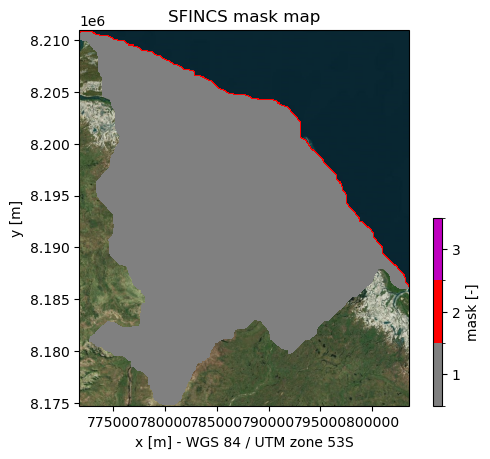

In [28]:
# 4: MASK component: Define active cells -------------------------------------------------------- 

# Define active cells within the combined basin polygon
sf.mask.create_active(include_polygon = total_polygon)

# Manual
waterlevel_boundary = sf.data_catalog.get_geodataframe("coastal_boundary_polygons") 

# This creates the coastal boundary as active cells 
sf.mask.create_boundary(
    btype='waterlevel',
    # include_polygon = "osm_water",
    # include_polygon_buffer = 10,  # buffer in meters around the coastline
    include_polygon = waterlevel_boundary,
    reset_bounds=True
)

fig, ax = sf.plot_basemap(
    variable="mask", plot_region=False, plot_bounds=False, bmap="sat", zoomlevel=12
)


2026-01-31 09:45:12,017 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover RasterDataset data from P:\wflow_global\hydromt\landuse\esa_worldcover\esa-worldcover.vrt
2026-01-31 09:45:23,176 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover_mapping DataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\esa_worldcover_mapping.csv
2026-01-31 09:46:00,692 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - WARNING - nan values in manning roughness array
2026-01-31 09:46:00,794 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - INFO - Set other manning options to None in config that are unused in SFINCS in case of specifying manningfile (manning, manning_land, manning_sea, rgh_lev_land).


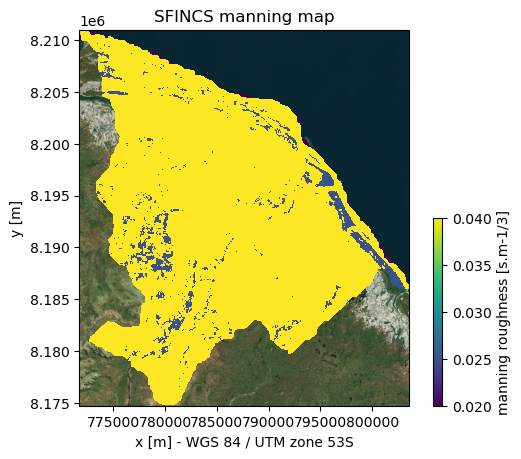

In [29]:
# Surface roughness setup --------------------------------------------------------
roughness_list = [
    {
        'lulc': 'esa_worldcover',                 # landuse/landcover dataset
        'reclass_table': 'esa_worldcover_mapping' # reclassification table
    }
]

sf.roughness.create(roughness_list)
# sf.roughness.data
_ = sf.plot_basemap(variable="manning", plot_bounds=False, bmap="sat", zoomlevel=12)

2026-01-28 09:48:30,637 - hydromt.hydromt_sfincs.components.grid.infiltration - infiltration - INFO - Creating curve number values for SFINCS with antecedent moisture condition: avg.
2026-01-28 09:48:30,643 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gcn250 RasterDataset data from P:\wflow_global\hydromt\landuse\gcn250\GCN250_ARCII.tif


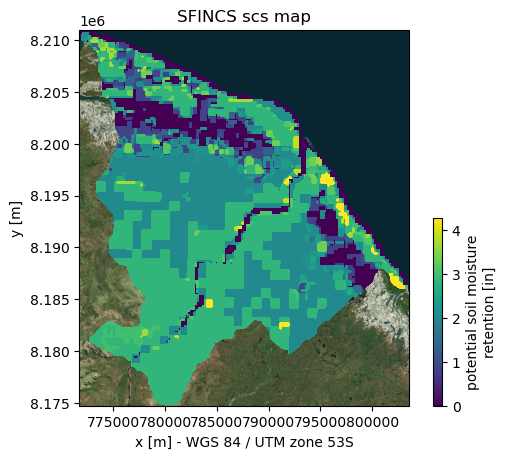

In [ ]:
# Infiltration data setup --------------------------------------------------------
# sf.infiltration.create_cn(
#     'gcn250', antecedent_moisture = 'avg', reproj_method= 'med' 
# )

# _ = sf.plot_basemap(variable="scs", plot_bounds=False, bmap="sat", zoomlevel=12)


In [37]:
# Add rivers data ----------------
rivers_clipped = catalog.get_geodataframe("global_rivers_lin", geom=total_polygon)

rivers_list = [
    {
        'centerlines': rivers_clipped # need rivwth and rivdph variable 
    }
]

# Riverine depth estimated using bankfull discharge Q --> Andreadis et al. (2013) --> Eilander paper and global rivers paper --> Leopold and Maddock, 1953

# Calculate bankfull discharge from GloFas at each river segment? (or take from Lin et al. 2019 paper) 
# Calculate depth (h) based on bankfull discharge (Q)
a = 0.27  
b = 0.30
rivers_clipped['rivdph'] = a * (rivers_clipped['Q2']**b)

# Verify the calculation 
print(rivers_clipped[['rivdph','rivwth', 'Q2']])


2026-01-31 09:51:59,398 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading global_rivers_lin GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\rivers_lin.gpkg
     rivdph     rivwth          Q2
1  1.527523  152.28017  322.661091
2  0.000000   95.88422    0.000000
3  0.000000   99.54481    0.000000
4  0.487188  198.22571    7.152241


In [38]:
# Set up sub-grid ---------------------------------------------------------
sf.subgrid.create(
    elevation_list= elevation_list,
    roughness_list = roughness_list,
    river_list = rivers_list,
    nr_subgrid_pixels = 10,             # 10 for 10m resolution,             # Fill in number of subgrid files
    write_dep_tif=True,                 # save a cloud-optimized geotiff of the subgrid topography
    write_man_tif=True,
    nrmax=5000,                         # set tile size a bit larger speed up processing (default 2000)
)

# make sure to write the updated model to the new model root before running sfincs
sf.write()

# sf.subgrid.data

2026-01-31 09:55:12,873 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit RasterDataset data from P:\wflow_global\hydromt\topography\merit\merit.nc
2026-01-31 09:55:13,129 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from P:\wflow_global\hydromt\bathymetry\gebco\gebco.vrt
2026-01-31 09:55:13,174 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover RasterDataset data from P:\wflow_global\hydromt\landuse\esa_worldcover\esa-worldcover.vrt
2026-01-31 09:55:21,934 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover_mapping DataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\esa_worldcover_mapping.csv
2026-01-31 09:55:22,031 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - Number of regular cells in a block : 500
2026-01-31 09:55:22,033 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - Number of blo

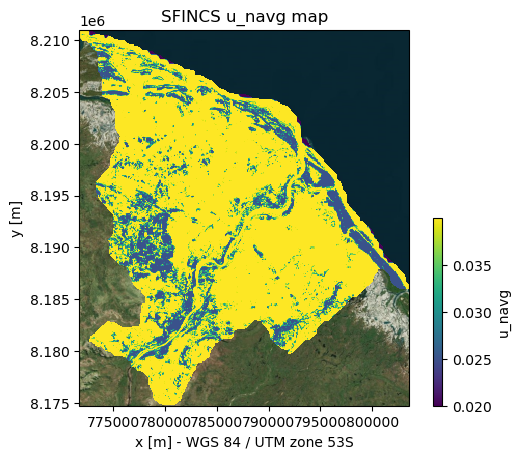

In [ ]:
# # we can plot the 2D subgrid variables
# _ = sf.plot_basemap(
#     variable=sf.subgrid.data["u_navg"], plot_bounds=False, bmap="sat", zoomlevel=12
# )

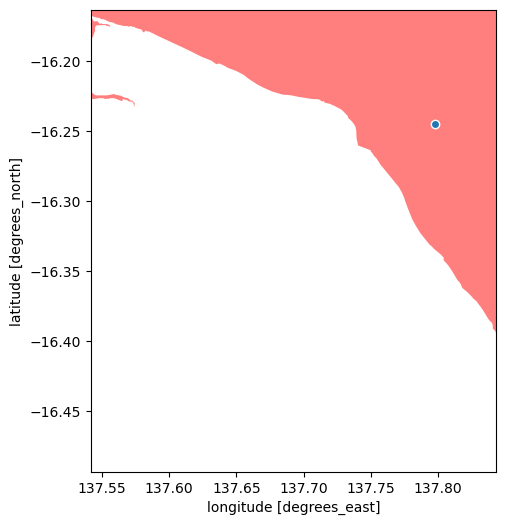

In [39]:
fn = r"p:\archivedprojects\11205028-c3s_435\01_data\01_Timeseries\timeseries2\waterlevel\reanalysis_waterlevel_hourly_2018_12_v1.nc"
ds = xr.open_dataset(fn)
# slice in space
fig, ax = plt.subplots(figsize=(8,6))
# change limits to bbox
ax.set_xlim(sf.bbox[0], sf.bbox[2])  
ax.set_ylim(sf.bbox[1], sf.bbox[3])
global_water.plot(ax=ax, color='red', label='Coastline', alpha = 0.5)
ds.plot.scatter(x="station_x_coordinate", y="station_y_coordinate", ax=ax)

In [40]:
# 4: Add forcing --------------------------------------------------------

sf.config.update(
    {
        "tref": datetime(2018, 12, 1), 
        "tstart": datetime(2018, 12, 1), 
        "tstop": datetime(2018, 12, 31), 
        "dtrstout":                         86400 # tells sfincs to save the simulation after each day (can also be trstout, but that'll only be one save
    }
)

# set up waterlevel forcing 
sf.water_level.create(geodataset = "gtsm_codec_reanalysis_waterlevel_hourly", 
                      buffer = 25e3) # aus delta

sf.water_level.data
# sf.plot_forcing()

# Manually create timeseries forcing - using GTSMS for 100-yr RP
# sf.water_level.create_timeseries(
#     shape = "gaussian", 
#     timestep = 600, # 10 minutes in seconds
#     offset = 0.0,
#     peak = 2.1, # based on GTSM data previously used 
#     tpeak = 3600 * 12, # peak at 12 hours
#     duration = 3600 * 36 # total duration of 36 hours (1.5 days)
# )


2026-01-31 09:57:34,920 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 4 attributes in model config.
2026-01-31 09:57:35,030 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gtsm_codec_reanalysis_waterlevel_hourly GeoDataset data from P:\archivedprojects\11205028-c3s_435\01_data\01_Timeseries\timeseries2\waterlevel\reanalysis_waterlevel_hourly_{year}_{month:02d}_v1.nc


<xarray.Dataset> Size: 12kB
Dimensions:      (time: 721, index: 1)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2018-12-01 ... 2018-12-31
  * index        (index) int64 8B 0
    geometry     (index) object 8B POINT (799095.8690450711 8201919.609102621)
    spatial_ref  int64 8B 0
Data variables:
    bzs          (time, index) float64 6kB 0.009 -0.173 -0.365 ... 0.442 0.399

2026-01-31 09:57:39,939 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading combined_dataset_deltas DataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\Combined_dataset_global_deltas.xlsx


(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'SFINCS waterlevel forcing (bzs)'}, ylabel='waterlevel\n[m+ref]'>,
        <Axes: title={'center': 'SFINCS discharge forcing (dis)'}, ylabel='discharge\n[m3.s-1]'>],
       dtype=object))

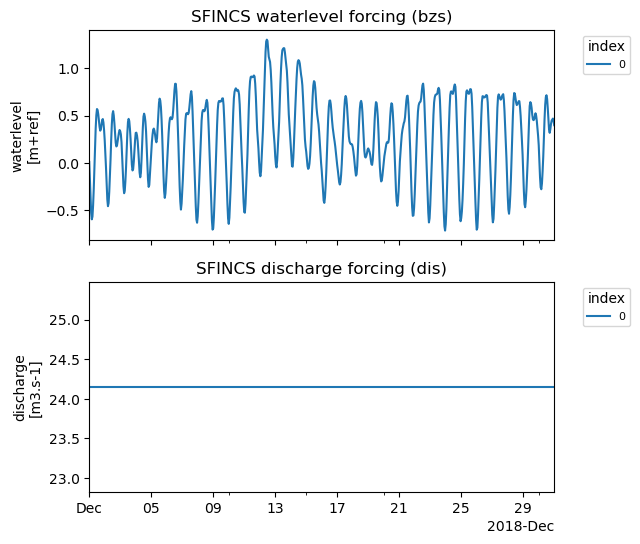

In [41]:
# Add rivers and discharge forcing  --------------------------------------------------------

# # Add river inflow points 
# sf.rivers.create_river_inflow(
#     hydrography='merit_hydro',
#     river_upa=100,                   # Minimum upstream area threshold for rivers [km2], by default 10.0
#     river_len=10,                    #  Mimimum river length within the model domain threshhold [m], by default 1 km.
#     keep_rivers_geom=True,
# )

# Add river inflow points 
sf.rivers.create_river_inflow(
    rivers=rivers_clipped,          # was 'global_rivers' before
    reverse_river_geom = True,                    
    keep_rivers_geom=True,
)

combined_dataset_deltas = catalog.get_dataframe('combined_dataset_deltas') 

# Create timeseries based on excel 
# NOTE the index 0 only adds discharge to the first river inflow point, the rest gets zero
sf.discharge_points.create_timeseries(
    index = [0],
    shape = "constant",
    offset = combined_dataset_deltas.loc[combined_dataset_deltas['BasinID2'] == target_basin_id, 'Discharge_dist'].values[0],
    # peak = combined_dataset_deltas.loc[combined_dataset_deltas['BasinID2'] == target_basin_id, 'Discharge99'].values[0],
    # tpeak = 15 * 86400,
    # duration = 2 * 86400,
    timestep = 600,
)

# Plot forcing 
sf.plot_forcing()

In [45]:
# Set up observation points 
obs_points_fn = sf.data_catalog.get_geodataframe("aus_obs_points")

# create points
sf.observation_points.create(locations=obs_points_fn, merge=False)


2026-01-31 10:11:51,264 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading aus_obs_points GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\aus_obs_points.geojson


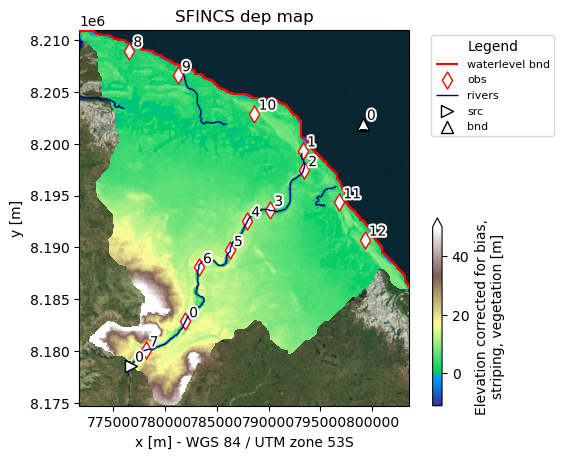

In [46]:
# Final plot of the model 
_ = sf.plot_basemap(variable='dep',bmap='sat')

In [47]:
# Save the model --------------------------------------------------------
sf.write()

2026-01-31 10:12:01,180 - hydromt.hydromt_sfincs.utils - utils - INFO - No changes detected; skipping write to C:\PhD\SFINCS\SFINCS_cloned\output\sfincs_620947_spinup\sfincs_netbndbzsbzifile.nc


In [48]:
# saving model creates a standard folder strcture that can be used to read in the model 
def print_directory_tree(directory):
    directory = str(directory)
    for root, dirs, files in os.walk(directory):
        level = root.replace(directory, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            print(f"{indent}  + {f}")

print_directory_tree(str(root_folder))

sfincs_620947_spinup/
  + hydromt_sfincs.log
  + run.bat
  + sfincs.20181202.000000.rst
  + sfincs.20181203.000000.rst
  + sfincs.20181204.000000.rst
  + sfincs.20181205.000000.rst
  + sfincs.20181206.000000.rst
  + sfincs.20181207.000000.rst
  + sfincs.20181208.000000.rst
  + sfincs.20181209.000000.rst
  + sfincs.20181210.000000.rst
  + sfincs.20181211.000000.rst
  + sfincs.20181212.000000.rst
  + sfincs.20181213.000000.rst
  + sfincs.20181214.000000.rst
  + sfincs.20181215.000000.rst
  + sfincs.20181216.000000.rst
  + sfincs.20181217.000000.rst
  + sfincs.20181218.000000.rst
  + sfincs.20181219.000000.rst
  + sfincs.20181220.000000.rst
  + sfincs.20181221.000000.rst
  + sfincs.20181222.000000.rst
  + sfincs.20181223.000000.rst
  + sfincs.20181224.000000.rst
  + sfincs.20181225.000000.rst
  + sfincs.20181226.000000.rst
  + sfincs.20181227.000000.rst
  + sfincs.20181228.000000.rst
  + sfincs.20181229.000000.rst
  + sfincs.20181230.000000.rst
  + sfincs.20181231.000000.rst
  + sfincs.de